In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import os

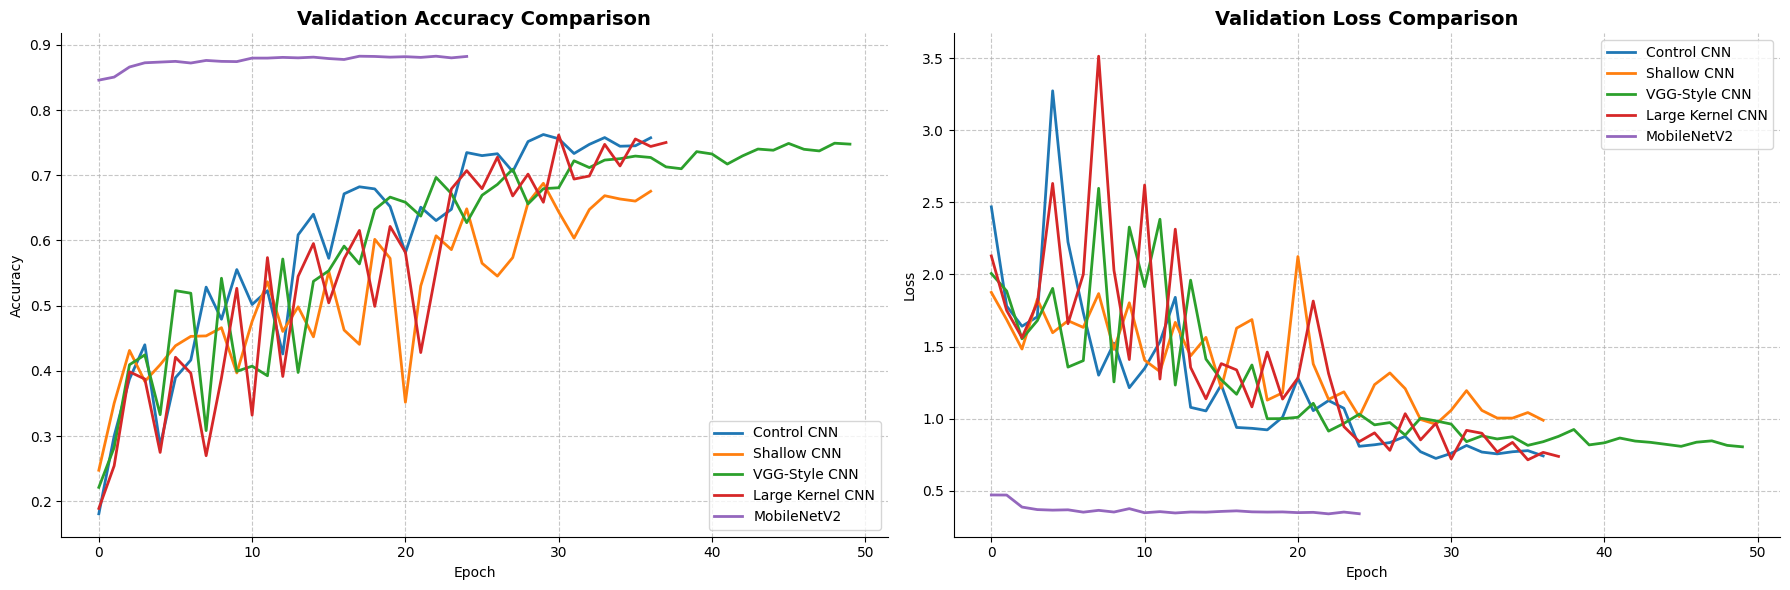

In [4]:
# Define the models and where to find their CSV logs
# Update the paths if your files are named differently!
models_to_plot = {
    'Control CNN': '../logs/experiments/control_history.csv',
    'Shallow CNN': '../logs/experiments/shallow_history.csv',
    'VGG-Style CNN': '../logs/experiments/vgg_style_history.csv',
    'Large Kernel CNN': '../logs/experiments/large_kernel_history.csv',
    'MobileNetV2': '../logs/mobile_net_v2_history.csv' # Adjust this path if needed
}

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Extended color palette for 5 models (added Purple for MobileNet)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for idx, (display_name, csv_path) in enumerate(models_to_plot.items()):
    if os.path.exists(csv_path):
        # Read the CSV into a DataFrame
        history_df = pd.read_csv(csv_path)
        
        # Plot Validation Accuracy
        ax[0].plot(history_df['val_accuracy'], label=display_name, color=colors[idx], linewidth=2)
        
        # Plot Validation Loss
        ax[1].plot(history_df['val_loss'], label=display_name, color=colors[idx], linewidth=2)
    else:
        print(f"⚠️ Warning: Could not find {csv_path}. Skipping {display_name}.")

# Format Accuracy Plot
ax[0].set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(loc='lower right')
ax[0].grid(True, linestyle='--', alpha=0.7)

# Format Loss Plot
ax[1].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(loc='upper right')
ax[1].grid(True, linestyle='--', alpha=0.7)

# Clean up borders for a professional look
for a in ax:
    for spine in ['top', 'right']:
        a.spines[spine].set_visible(False)
    
plt.tight_layout()
plt.show()

In [6]:
# %%
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
from utils.model_architectures import build_experimental_model

# 1. Import your configuration and data loader
from config import IMG_SIZE, BATCH_SIZE, CLASSES, SEED  # Ensure you use CNN_IMG_SIZE if you split them!
from utils.preprocess_data import get_garbage_datasets

print("1. Rebuilding Validation Dataset...")
image_categories_path = '../data/images'

# Re-instantiate the datasets (we only really need val_ds, but the function returns both)
train_ds, val_ds, class_names = get_garbage_datasets(
    data_dir=image_categories_path, 
    batch_size=BATCH_SIZE, 
    img_size=IMG_SIZE, 
    seed=SEED,
    model_type='custom' 
)
print("Dataset rebuilt successfully!")


# Define the Evaluation Plotter
def evaluate_and_plot(y_true, y_pred, class_names, model_name="Model"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
    plt.xlabel('Predicted Label', fontweight='bold')
    plt.ylabel('True Label', fontweight='bold')
    plt.title(f'Confusion Matrix: {model_name}', fontsize=14, fontweight='bold')
    plt.show()

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    accuracy = np.mean(y_true == y_pred)
    
    metrics_df = pd.DataFrame({
        'Model': [model_name],
        'Accuracy': [round(accuracy, 4)],
        'Macro Precision': [round(precision, 4)],
        'Macro Recall': [round(recall, 4)],
        'Macro F1-Score': [round(f1, 4)]
    })
    
    print(f"\n--- Detailed Classification Report: {model_name} ---")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    return metrics_df

1. Rebuilding Validation Dataset...
Found 13901 files belonging to 6 classes.
Using 11121 files for training.


2026-05-23 01:58:37.110702: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-05-23 01:58:37.110735: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-23 01:58:37.110741: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-05-23 01:58:37.110755: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-23 01:58:37.110764: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 13901 files belonging to 6 classes.
Using 2780 files for validation.
Dataset rebuilt successfully!


Extracting validation images and labels...


2026-05-23 01:59:37.298233: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Loaded 2780 validation images.

🔍 EVALUATING: CONTROL
Successfully loaded weights for control.
Generating predictions...


/Users/kvbek/Documents/projects/garbage-sorting-model/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


 1/87 ━━━━━━━━━━━━━━━━━━━━ 18s 211ms/step

2026-05-23 01:59:38.410727: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step


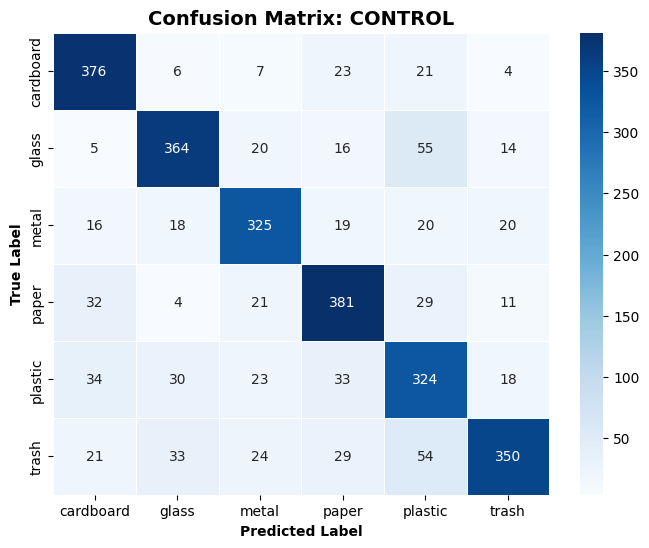


--- Detailed Classification Report: CONTROL ---
              precision    recall  f1-score   support

   cardboard       0.78      0.86      0.82       437
       glass       0.80      0.77      0.78       474
       metal       0.77      0.78      0.78       418
       paper       0.76      0.80      0.78       478
     plastic       0.64      0.70      0.67       462
       trash       0.84      0.68      0.75       511

    accuracy                           0.76      2780
   macro avg       0.77      0.76      0.76      2780
weighted avg       0.77      0.76      0.76      2780


🔍 EVALUATING: SHALLOW
Successfully loaded weights for shallow.
Generating predictions...


/Users/kvbek/Documents/projects/garbage-sorting-model/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


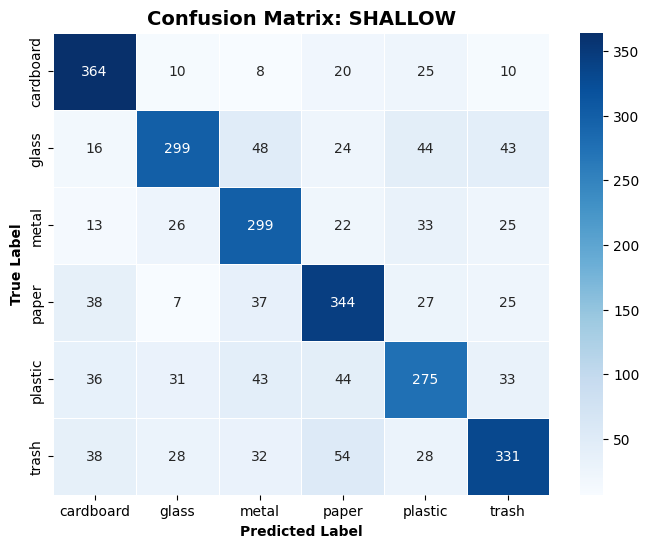


--- Detailed Classification Report: SHALLOW ---
              precision    recall  f1-score   support

   cardboard       0.72      0.83      0.77       437
       glass       0.75      0.63      0.68       474
       metal       0.64      0.72      0.68       418
       paper       0.68      0.72      0.70       478
     plastic       0.64      0.60      0.62       462
       trash       0.71      0.65      0.68       511

    accuracy                           0.69      2780
   macro avg       0.69      0.69      0.69      2780
weighted avg       0.69      0.69      0.69      2780


🔍 EVALUATING: VGG_STYLE
Successfully loaded weights for vgg_style.
Generating predictions...


/Users/kvbek/Documents/projects/garbage-sorting-model/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step


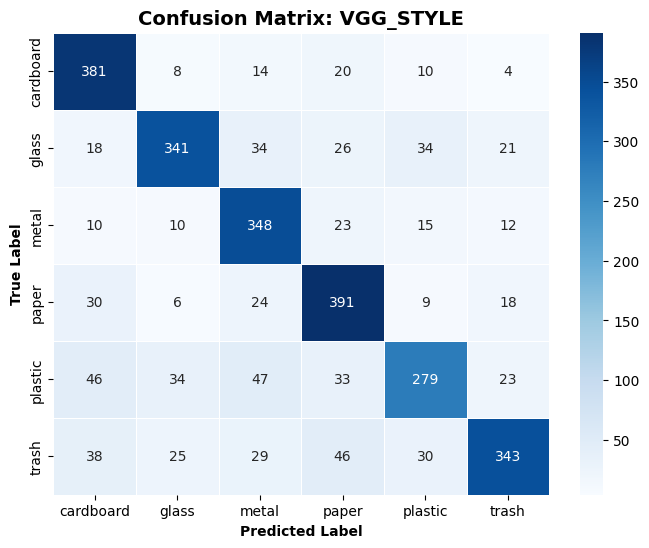


--- Detailed Classification Report: VGG_STYLE ---
              precision    recall  f1-score   support

   cardboard       0.73      0.87      0.79       437
       glass       0.80      0.72      0.76       474
       metal       0.70      0.83      0.76       418
       paper       0.73      0.82      0.77       478
     plastic       0.74      0.60      0.67       462
       trash       0.81      0.67      0.74       511

    accuracy                           0.75      2780
   macro avg       0.75      0.75      0.75      2780
weighted avg       0.75      0.75      0.75      2780


🔍 EVALUATING: LARGE_KERNEL
Successfully loaded weights for large_kernel.
Generating predictions...


/Users/kvbek/Documents/projects/garbage-sorting-model/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step


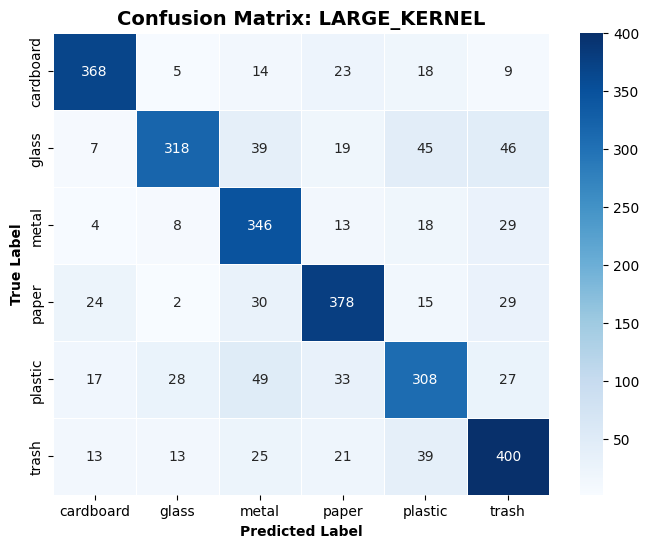


--- Detailed Classification Report: LARGE_KERNEL ---
              precision    recall  f1-score   support

   cardboard       0.85      0.84      0.85       437
       glass       0.85      0.67      0.75       474
       metal       0.69      0.83      0.75       418
       paper       0.78      0.79      0.78       478
     plastic       0.70      0.67      0.68       462
       trash       0.74      0.78      0.76       511

    accuracy                           0.76      2780
   macro avg       0.77      0.76      0.76      2780
weighted avg       0.77      0.76      0.76      2780


🏆 FINAL EXPERIMENT RESULTS 🏆


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
0,CONTROL,0.7626,0.7658,0.7649,0.7633
1,SHALLOW,0.6878,0.6882,0.6903,0.6870
2,VGG_STYLE,0.7493,0.7524,0.7528,0.7475
3,LARGE_KERNEL,0.7619,0.7667,0.7635,0.7621


In [7]:
# 1. Extract validation data ONCE so it is perfectly consistent for all models
print("Extracting validation images and labels...")
val_images = []
val_labels = []
for images, labels in val_ds.unbatch():
    val_images.append(images.numpy())
    val_labels.append(labels.numpy())

val_images = np.array(val_images)
val_labels = np.array(val_labels)
print(f"Loaded {len(val_images)} validation images.")

# 2. List the models you want to evaluate
architectures_to_evaluate = ['control', 'shallow', 'vgg_style', 'large_kernel']
all_metrics = []

# 3. Loop through, rebuild, load, and evaluate
for arch in architectures_to_evaluate:
    print(f"\n{'='*50}")
    print(f"🔍 EVALUATING: {arch.upper()}")
    print(f"{'='*50}")
    
    # A. Build the empty "brain" 
    model = build_experimental_model(arch, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    
    # B. Define where the weights file is saved
    weights_path = f'../models/experiments/{arch}_best.weights.h5'
    
    if os.path.exists(weights_path):
        # C. Load the "memories" into the model
        model.load_weights(weights_path)
        print(f"Successfully loaded weights for {arch}.")
        
        # D. Make predictions
        print("Generating predictions...")
        predictions = model.predict(val_images)
        predicted_classes = np.argmax(predictions, axis=1)
        
        # E. Run evaluation function
        metrics_df = evaluate_and_plot(
            y_true=val_labels, 
            y_pred=predicted_classes, 
            class_names=CLASSES, 
            model_name=arch.upper()
        )
        all_metrics.append(metrics_df)
    else:
        print(f"⚠️ Warning: Could not find weights at {weights_path}. Skipping.")

# 4. Combine all the metrics into one final table
if all_metrics:
    final_results_df = pd.concat(all_metrics, ignore_index=True)
    
    print("\n🏆 FINAL EXPERIMENT RESULTS 🏆")
    display(final_results_df)
    
    # Save this final table to a CSV
    final_results_df.to_csv('../logs/experiments/final_metrics_comparison.csv', index=False)